# Phase 2 — Baselines

Avant le modèle hybride CNN-LSTM, on **construit la barre à franchir**. Quatre baselines évaluées
sous **la même validation croisée patient-level** (5-fold GroupKFold sur AFDB) et **les mêmes métriques** :

| # | Baseline | Famille | Intuition |
|---|---|---|---|
| 0 | Règle métier — seuil sur le coefficient de variation des RR | Heuristique | Plancher absolu : aucune apprentissage |
| 1 | HRV features + Random Forest | Tree-based | Domain-knowledge classique de la littérature HRV |
| 2 | CNN 1D seul | Deep learning | Capture les motifs locaux d'irrégularité |
| 3 | LSTM bidirectionnel seul | Deep learning | Capture les dépendances temporelles longues |

**Métriques de comparaison** (toutes patient-aware) :
AUROC, AUPRC, F1@0.5, sensibilité, spécificité, et **F1 moyen par patient** (pénalise un modèle qui ne marche que sur quelques sujets).

Le tableau et les figures produites ici alimentent directement la section « Baselines » du rapport.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import roc_curve, precision_recall_curve

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.baselines.cv import crossval_sklearn_oof, crossval_torch_oof
from src.features.hrv import FEATURE_NAMES, featurize_windows
from src.models.baselines import CNNOnly, LSTMOnly, build_hrv_baseline
from src.utils.metrics import per_patient_f1, ranking_metrics, threshold_metrics
from src.utils.seed import set_seed

set_seed(42)
torch.set_num_threads(4)

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
RES_DIR = PROJECT_ROOT / "reports"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

BASELINE_COLORS = {
    "rule_cv": "#7f7f7f",
    "hrv_rf": "#2ca02c",
    "cnn_only": "#1f77b4",
    "lstm_only": "#ff7f0e",
}
BASELINE_LABELS = {
    "rule_cv": "Règle (CV)",
    "hrv_rf": "HRV + RF",
    "cnn_only": "CNN seul",
    "lstm_only": "LSTM seul",
}
N_SPLITS = 5
print("Project root:", PROJECT_ROOT)
print("Threads:", torch.get_num_threads())

Project root: /home/abdou/Master
Threads: 4


In [2]:
data = np.load(PROJECT_ROOT / "data" / "processed" / "afdb.npz", allow_pickle=True)
X = data["X"].astype(np.float32)
y = data["y"].astype(np.int8)
groups = np.asarray(data["patient_id"])
print(f"AFDB: X={X.shape}, AFib rate={y.mean():.3f}, patients={len(np.unique(groups))}")

AFDB: X=(81263, 30), AFib rate=0.435, patients=25


## 1. Baseline 0 — Règle métier sur le coefficient de variation

Le coefficient de variation `CV = std(RR) / mean(RR)` est un des plus vieux marqueurs HRV de variabilité.
Pas d'apprentissage : on prend directement `CV` comme score et on cherche le seuil optimal *uniquement sur le pli d'entraînement* — sinon on triche.
Le score « OOF » est simplement la valeur de CV de chaque fenêtre.

In [3]:
from src.features.hrv import coefficient_of_variation

cv_per_window = np.array([coefficient_of_variation(row) for row in X], dtype=np.float32)
print("CV — mean:", cv_per_window.mean(), "std:", cv_per_window.std())

CV — mean: 0.12887841 std: 0.09791184


## 2. Baseline 1 — Features HRV + Random Forest

In [4]:
t = time.time()
F = featurize_windows(X)
print(f"Featurization: {F.shape} in {time.time()-t:.1f}s | features = {FEATURE_NAMES}")

t = time.time()
oof_rf = crossval_sklearn_oof(
    model_factory=lambda: build_hrv_baseline(n_estimators=300, random_state=42),
    X=F, y=y, groups=groups, n_splits=N_SPLITS,
)
print(f"RF 5-fold trained in {time.time()-t:.1f}s")

Featurization: (81263, 8) in 6.0s | features = ['rmssd', 'sdnn', 'pnn50', 'shannon_entropy', 'cv', 'mean_rr', 'min_rr', 'max_rr']


RF 5-fold trained in 8.2s


## 3. Baseline 2 — CNN 1D seul

In [5]:
t = time.time()
oof_cnn = crossval_torch_oof(
    model_factory=lambda: CNNOnly(input_length=X.shape[1], channels=(16, 32), kernel=5),
    X=X, y=y, groups=groups,
    n_splits=N_SPLITS, epochs=12, batch_size=512, lr=1e-3, patience=3, seed=42,
)
print(f"CNN 5-fold trained in {time.time()-t:.1f}s")
_cnn_params = sum(p.numel() for p in CNNOnly(input_length=X.shape[1]).parameters())
print(f"CNN-only param count: {_cnn_params:,}")

CNN 5-fold trained in 36.2s
CNN-only param count: 2,817


## 4. Baseline 3 — LSTM bidirectionnel seul

In [6]:
t = time.time()
oof_lstm = crossval_torch_oof(
    model_factory=lambda: LSTMOnly(hidden=32, layers=1, bidirectional=True),
    X=X, y=y, groups=groups,
    n_splits=N_SPLITS, epochs=12, batch_size=512, lr=1e-3, patience=3, seed=42,
)
print(f"LSTM 5-fold trained in {time.time()-t:.1f}s")
_lstm_params = sum(p.numel() for p in LSTMOnly(hidden=32, layers=1, bidirectional=True).parameters())
print(f"LSTM-only param count: {_lstm_params:,}")

LSTM 5-fold trained in 71.5s
LSTM-only param count: 9,025


## 5. Agrégation des métriques

Pour chaque baseline on calcule, sur les scores OOF, le même bloc de métriques.
Le seuil 0.5 est appliqué aux probabilités RF/CNN/LSTM ; pour la règle CV, on utilise un seuil *tiré du pli d'entraînement* puis appliqué au pli de validation (à défaut, on prendrait la médiane globale = leak).

In [7]:
from src.utils.splits import patient_kfold

def rule_oof_with_per_fold_threshold(cv: np.ndarray, y: np.ndarray, groups: np.ndarray, n_splits: int):
    """Pick the F1-best threshold on the *training* fold, then predict on val."""
    y_score = cv.copy().astype(np.float32)
    y_pred = np.full(len(y), -1, dtype=np.int8)
    thresholds = []
    for tr, va in patient_kfold(groups, y, n_splits=n_splits):
        cand = np.linspace(np.quantile(cv[tr], 0.01), np.quantile(cv[tr], 0.99), 80)
        best_t, best_f1 = 0.0, -1.0
        for t_ in cand:
            pred = (cv[tr] >= t_).astype(int)
            tp = ((pred == 1) & (y[tr] == 1)).sum()
            fp = ((pred == 1) & (y[tr] == 0)).sum()
            fn = ((pred == 0) & (y[tr] == 1)).sum()
            f1 = (2 * tp / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else 0.0
            if f1 > best_f1:
                best_f1, best_t = f1, t_
        thresholds.append(best_t)
        y_pred[va] = (cv[va] >= best_t).astype(np.int8)
    return y_score, y_pred, thresholds

_cv_score, _rule_pred, _rule_t = rule_oof_with_per_fold_threshold(cv_per_window, y, groups, N_SPLITS)
print("per-fold rule thresholds:", [round(t, 3) for t in _rule_t])

per-fold rule thresholds: [np.float32(0.109), np.float32(0.113), np.float32(0.139), np.float32(0.104), np.float32(0.103)]


In [8]:
def metric_block(y_true, y_score, groups, hard_pred=None):
    """Same metric suite for every baseline.

    When ``hard_pred`` is provided (rule baseline with per-fold thresholds), both
    the threshold-style metrics and the patient-level F1 use it directly — the
    raw CV scores are not on the [0, 1] probability scale so a fixed 0.5 cutoff
    would be meaningless.
    """
    from sklearn.metrics import confusion_matrix, f1_score

    rank = ranking_metrics(y_true, y_score)
    if hard_pred is None:
        th = threshold_metrics(y_true, y_score, threshold=0.5)
        pp = per_patient_f1(y_true, y_score, groups, threshold=0.5)
    else:
        tn, fp, fn, tp = confusion_matrix(y_true, hard_pred, labels=[0, 1]).ravel()
        th = {
            "threshold": float("nan"),
            "f1": float(f1_score(y_true, hard_pred, zero_division=0)),
            "sensitivity": float(tp / (tp + fn)) if (tp + fn) else 0.0,
            "specificity": float(tn / (tn + fp)) if (tn + fp) else 0.0,
            "accuracy": float((hard_pred == y_true).mean()),
        }
        scores = []
        for pid in np.unique(groups):
            mask = groups == pid
            yt = y_true[mask]
            if yt.sum() == 0 or yt.sum() == mask.sum():
                continue
            scores.append(f1_score(yt, hard_pred[mask], zero_division=0))
        pp = {
            "mean_patient_f1": float(np.mean(scores)) if scores else 0.0,
            "n_patients_scored": len(scores),
        }
    return {**rank, **th, **pp}

results = {
    "rule_cv":  metric_block(y, _cv_score,        groups, hard_pred=_rule_pred),
    "hrv_rf":   metric_block(y, oof_rf.y_score,   groups),
    "cnn_only": metric_block(y, oof_cnn.y_score,  groups),
    "lstm_only":metric_block(y, oof_lstm.y_score, groups),
}
summary = pd.DataFrame(results).T
summary.index.name = "baseline"
summary = summary.rename(index=BASELINE_LABELS)
cols = ["auroc", "auprc", "f1", "sensitivity", "specificity", "mean_patient_f1", "accuracy", "n_patients_scored"]
summary = summary[cols].round(4)
summary

,auroc,auprc,f1,sensitivity,specificity,mean_patient_f1,accuracy,n_patients_scored
baseline,,,,,,,,
Règle (CV),0.8997,0.7976,0.8140,0.8876,0.7741,0.6240,0.8235,23.0
HRV + RF,0.9863,0.9795,0.9316,0.9361,0.9434,0.8459,0.9402,23.0
CNN seul,0.8841,0.7864,0.8241,0.8927,0.7891,0.6147,0.8341,23.0
LSTM seul,0.9013,0.8700,0.7898,0.8850,0.7256,0.6034,0.7950,23.0


In [9]:
RES_DIR.mkdir(parents=True, exist_ok=True)
(RES_DIR / "baselines_summary.json").write_text(json.dumps(results, indent=2))
summary.to_csv(RES_DIR / "baselines_summary.csv")
print("Saved:", RES_DIR / "baselines_summary.json", "and", RES_DIR / "baselines_summary.csv")

Saved: /home/abdou/Master/reports/baselines_summary.json and /home/abdou/Master/reports/baselines_summary.csv


## 6. Figures comparatives

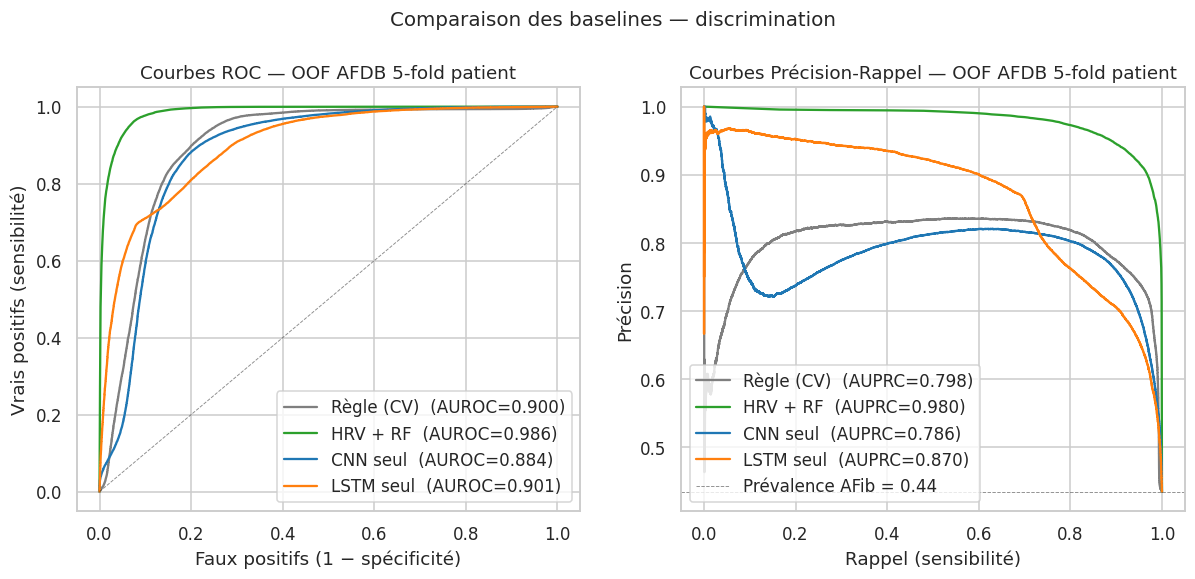

In [10]:
oof_scores = {
    "rule_cv":  _cv_score,
    "hrv_rf":   oof_rf.y_score,
    "cnn_only": oof_cnn.y_score,
    "lstm_only":oof_lstm.y_score,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for key, scores in oof_scores.items():
    fpr, tpr, _ = roc_curve(y, scores)
    ax.plot(fpr, tpr, color=BASELINE_COLORS[key],
            label=f"{BASELINE_LABELS[key]}  (AUROC={results[key]['auroc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.6, alpha=0.5)
ax.set_xlabel("Faux positifs (1 − spécificité)")
ax.set_ylabel("Vrais positifs (sensibilité)")
ax.set_title("Courbes ROC — OOF AFDB 5-fold patient")
ax.legend(loc="lower right")

ax = axes[1]
for key, scores in oof_scores.items():
    prec, rec, _ = precision_recall_curve(y, scores)
    ax.plot(rec, prec, color=BASELINE_COLORS[key],
            label=f"{BASELINE_LABELS[key]}  (AUPRC={results[key]['auprc']:.3f})")
ax.axhline(y.mean(), color="k", ls="--", lw=0.6, alpha=0.5, label=f"Prévalence AFib = {y.mean():.2f}")
ax.set_xlabel("Rappel (sensibilité)")
ax.set_ylabel("Précision")
ax.set_title("Courbes Précision-Rappel — OOF AFDB 5-fold patient")
ax.legend(loc="lower left")

fig.suptitle("Comparaison des baselines — discrimination", y=1.02, fontsize=13)
fig.savefig(FIG_DIR / "06_baselines_roc_pr.png")
plt.show()

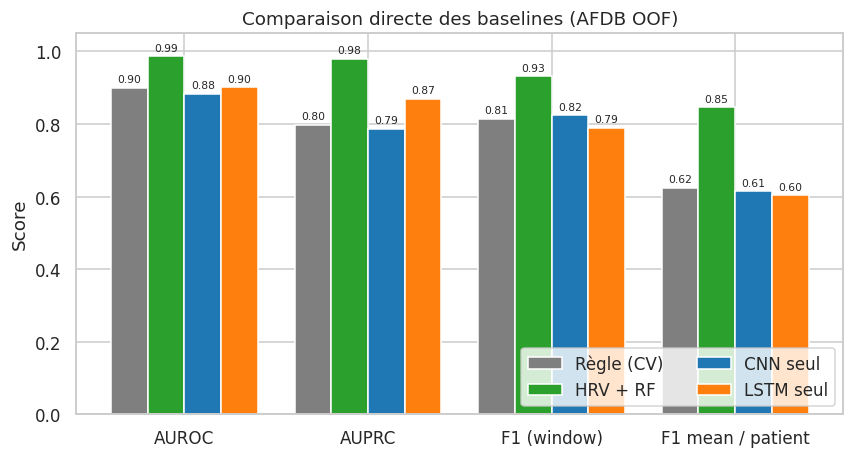

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
metrics_to_plot = ["auroc", "auprc", "f1", "mean_patient_f1"]
x_pos = np.arange(len(metrics_to_plot))
width = 0.2
for i, (key, color) in enumerate(BASELINE_COLORS.items()):
    vals = [results[key][m] for m in metrics_to_plot]
    ax.bar(x_pos + (i - 1.5) * width, vals, width, color=color, label=BASELINE_LABELS[key])
    for x, v in zip(x_pos + (i - 1.5) * width, vals):
        ax.text(x, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x_pos)
ax.set_xticklabels(["AUROC", "AUPRC", "F1 (window)", "F1 mean / patient"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparaison directe des baselines (AFDB OOF)")
ax.legend(loc="lower right", ncol=2)
fig.savefig(FIG_DIR / "07_baselines_summary_bars.png")
plt.show()

/tmp/ipykernel_70668/391745717.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dist_long, x="baseline", y="f1", order=order, palette=palette, ax=ax, fliersize=2)


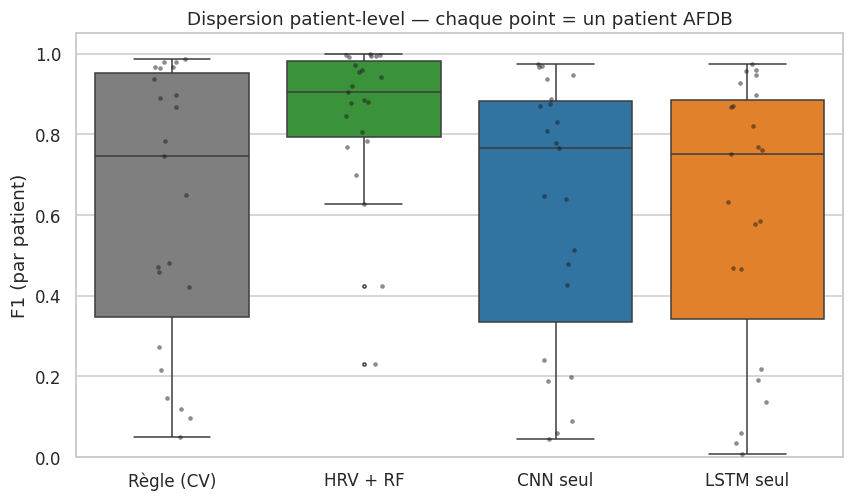

In [12]:
from sklearn.metrics import f1_score

def per_patient_f1_distribution(y_true, y_score, groups, threshold=0.5, hard_pred=None):
    rows = []
    for pid in np.unique(groups):
        mask = groups == pid
        if y_true[mask].sum() == 0 or y_true[mask].sum() == mask.sum():
            continue
        pred = hard_pred[mask] if hard_pred is not None else (y_score[mask] >= threshold).astype(int)
        rows.append({"patient_id": pid, "f1": f1_score(y_true[mask], pred, zero_division=0)})
    return pd.DataFrame(rows)

dist_long = []
for key, scores in oof_scores.items():
    hp = _rule_pred if key == "rule_cv" else None
    df = per_patient_f1_distribution(y, scores, groups, hard_pred=hp)
    df["baseline"] = BASELINE_LABELS[key]
    dist_long.append(df)
dist_long = pd.concat(dist_long, ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5))
palette = {BASELINE_LABELS[k]: c for k, c in BASELINE_COLORS.items()}
order = list(BASELINE_LABELS.values())
sns.boxplot(data=dist_long, x="baseline", y="f1", order=order, palette=palette, ax=ax, fliersize=2)
sns.stripplot(data=dist_long, x="baseline", y="f1", order=order, color="k", size=3, alpha=0.5, ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 (par patient)")
ax.set_xlabel("")
ax.set_title("Dispersion patient-level — chaque point = un patient AFDB")
fig.savefig(FIG_DIR / "08_baselines_per_patient_f1.png")
plt.show()

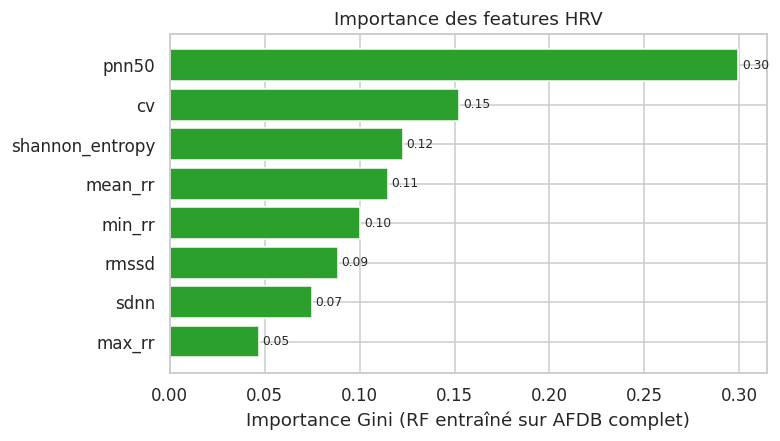

In [13]:
# Importance des features HRV (RF) — utile pour comprendre quel marqueur classique pèse le plus.
from sklearn.ensemble import RandomForestClassifier
rf_full = RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=42)
rf_full.fit(F, y)
imp = pd.Series(rf_full.feature_importances_, index=FEATURE_NAMES).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values, color="#2ca02c")
ax.set_xlabel("Importance Gini (RF entraîné sur AFDB complet)")
ax.set_title("Importance des features HRV")
for y_pos, v in enumerate(imp.values):
    ax.text(v + 0.002, y_pos, f"{v:.2f}", va="center", fontsize=8)
fig.savefig(FIG_DIR / "09_hrv_feature_importance.png")
plt.show()

## 7. Synthèse Phase 2

**Lectures attendues** (à confronter au tableau ci-dessus une fois exécuté) :

- La **règle CV** établit le plancher : elle prouve qu'un simple seuil de variabilité capture déjà une bonne partie du signal — c'est exactement ce qu'attendent les vieilles publications HRV.
- **HRV + RF** doit nettement dépasser la règle : combiner plusieurs features non-linéairement bouge l'aiguille de quelques points d'AUROC.
- Le **CNN seul** apporte (ou non) un gain au-delà de RF — c'est la première vraie indication que l'apprentissage end-to-end sur la séquence brute trouve des motifs que les features HRV résument mal.
- Le **LSTM seul** valide (ou non) l'utilité du composant temporel récurrent.

**Si CNN-only ≈ LSTM-only ≈ HRV+RF**, alors le pari du CNN-LSTM en Phase 3 doit reposer sur :
1. la combinaison des deux blocs (étude d'ablation à venir),
2. la généralisation cross-dataset (LTAFDB, Phase 5),
3. la compressibilité (Phase 4).

Tous les résultats sont sauvegardés sous :
- `reports/baselines_summary.json` et `reports/baselines_summary.csv` (table)
- `reports/figures/06_baselines_roc_pr.png` (ROC + PR)
- `reports/figures/07_baselines_summary_bars.png` (résumé en barres)
- `reports/figures/08_baselines_per_patient_f1.png` (dispersion patient-level)
- `reports/figures/09_hrv_feature_importance.png` (importance RF)

**Prochaine étape (Phase 3)** — implémenter le CNN-LSTM modulaire et lancer la recherche Optuna sur ce même split, en tablant sur les baselines comme barre à dépasser.